## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 02 · Engine inputs per dwelling, representatives and the calibration interface

Following Dogan et al. (2025), the archetypes are not "one building per cluster": **every dwelling keeps its own
geometry** and the archetype supplies the fabric inputs' feasible ranges. This notebook exports:

* **`dwelling_inputs.parquet`** — one row per dwelling: identifiers, geometry, its own U-values, archetype
  labels, the archetype's fabric medians and p5–p95 ranges;
* **`cluster_representatives.json` / `.csv`** — the medoid of every sub-archetype in the clustering feature
  space (the dwelling the calibration and the hourly runs simulate for its group), with modal typology and
  median geometry;
* **`calibration_targets_lsoa.csv`** — the LSOA × sub-archetype composition joined to the DESNZ LSOA gas and
  electricity means, the aggregation the calibration objective uses.

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()
print(f"EnerMap - {STUDY_AREA}   |   cores: {N_JOBS}")

EnerMap - Guildford   |   cores: 32


In [2]:
import joblib
dwc = pd.read_parquet(DATA_WITH_CLUSTERS)
labels = pd.read_parquet(TABLE_LABELS)
cl_model = joblib.load(CLUSTERS_DIR / "clustering_model.pkl")
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
lookup = pd.read_csv(ARCHETYPE_LOOKUP).set_index("cluster")
names = lookup["construction_sa"].to_dict()
clabels = pd.read_csv(CLUSTER_LABELS_CSV, index_col=0)
lab = labels.join(dwc[["cluster", "wall_U", "roof_U", "window_U", "window_SHGC", "floor_area_final", "storeys_est", "height_eaves_m",
                       "height_ridge_m", "area_m2", "volume_m3", "uprn_count", "age_band_ord", "roof_exposed", "is_flat_roof", "EPh_sap"]])
for c in ("systems_fam", "archetype"):
    lab[c] = clabels[c].reindex(lab.index)
cluster_ids = sorted(dwc["cluster"].unique())
print(f"{len(lab):,} dwellings, {len(cluster_ids)} construction sub-archetypes")

57,300 dwellings, 34 construction sub-archetypes


## 1 · Medoids and representative specifications

In [3]:
geom = ["floor_area_final", "storeys_est", "height_eaves_m", "height_ridge_m", "area_m2", "volume_m3", "uprn_count"]
fabric_cols = ["wall_U", "roof_U", "window_U", "window_SHGC", "age_band_ord"]
typology = ["accommodation_type", "built_form", "age_band_resolved", "heat_system", "wall_construction_resolved", "wall_insulation", "glazing_type", "roof_type", "tenure"]
# distance of every dwelling to its cluster centre, in the space the clustering was done in
dist = pd.Series(np.nan, index=dwc.index)
for stratum, f in cl_model["strata"].items():
    idx = lab.index[lab[STRATA_COL] == stratum]
    Xs = f["encoder"].transform(lab.loc[idx])
    m = f["model"]; centres = m.cluster_centers_ if hasattr(m, "cluster_centers_") else m.means_
    dist.loc[idx] = np.linalg.norm(Xs - centres[m.predict(Xs)], axis=1)
rest = dist.index[dist.isna()]                                   # single-archetype strata
z = (dwc.loc[rest, fabric_cols] - dwc.loc[rest, fabric_cols].median()) / (dwc.loc[rest, fabric_cols].std() + 1e-9)
dist.loc[rest] = np.linalg.norm(z.fillna(0).values, axis=1)
medoid_id = dist.groupby(dwc["cluster"]).idxmin()
representatives, rows = {}, []
for cid in cluster_ids:
    c = lab[lab["cluster"] == cid]; med = c.loc[medoid_id[cid]]
    spec = {"archetype": names[cid], "n_dwellings": int(len(c)), "share_of_stock_pct": round(100 * len(c) / len(lab), 2),
            "synthesised_share_pct": round(100 * (1 - c["attributes_observed"].mean()), 1), "in_study_area_pct": round(100 * c["in_study_area"].mean(), 1),
            "systems_family_shares_pct": (c["systems_fam"].value_counts(normalize=True) * 100).round(1).to_dict(),
            "medoid": {"dwelling_id": int(medoid_id[cid]), "UPRN": med["UPRN"], "LSOA": med["LSOA"], **{k: med[k] for k in typology}, **{k: float(med[k]) for k in geom + fabric_cols}},
            "typology_mode": {k: H.mode_or_none(c[k]) for k in typology},
            "typology_shares_pct": {k: (c[k].value_counts(normalize=True).head(4) * 100).round(1).to_dict() for k in typology},
            "geometry_median": {k: float(c[k].median()) for k in geom},
            "fabric": {k: {"initial_guess": float(c[k].median()), "feasible_range": [float(c[k].quantile(0.05)), float(c[k].quantile(0.95))]} for k in fabric_cols},
            "roof_exposed_share": float(c["roof_exposed"].mean()),
            "certificate_kWh_m2_median": float(c["EPh_sap"].median()) if c["EPh_sap"].notna().any() else None}
    representatives[int(cid)] = spec
    rows.append({"cluster": cid, "archetype": names[cid], "n": len(c), "medoid_dwelling_id": int(medoid_id[cid]),
                 **{f"mode_{k}": spec["typology_mode"][k] for k in typology}, **{f"median_{k}": round(v, 2) for k, v in spec["geometry_median"].items()},
                 **{f"{k}_median": round(spec["fabric"][k]["initial_guess"], 3) for k in ("wall_U", "window_U", "roof_U")},
                 "certificate_kWh_m2_median": spec["certificate_kWh_m2_median"]})
rep_table = pd.DataFrame(rows).set_index("cluster")
json.dump(H.json_safe(representatives), open(EXPORT_DIR / "cluster_representatives.json", "w"), indent=2)
rep_table.to_csv(EXPORT_DIR / "cluster_representatives.csv")
rep_table[["archetype", "n", "mode_accommodation_type", "mode_age_band_resolved", "mode_wall_construction_resolved", "mode_wall_insulation", "mode_glazing_type",
           "mode_heat_system", "median_floor_area_final", "wall_U_median", "window_U_median", "certificate_kWh_m2_median"]]

,archetype,n,mode_accommodation_type,mode_age_band_resolved,mode_wall_construction_resolved,mode_wall_insulation,mode_glazing_type,mode_heat_system,median_floor_area_final,wall_U_median,window_U_median,certificate_kWh_m2_median
cluster,,,,,,,,,,,,
0,C.Det.1,5004,Detached,D,Cavity,Insulated,Double,Gas boiler,143.00,0.70,3.02,203.0
1,C.Det.2,3570,Detached,C,Cavity,Uninsulated,Double,Gas boiler,147.00,1.50,3.02,249.0
2,C.Det.3,3440,Detached,G,Cavity,Insulated,Double,Gas boiler,145.50,0.35,3.02,178.0
3,C.Det.4,2056,Detached,L,Cavity,Insulated,Triple/High performance,Gas boiler,147.30,0.24,1.80,72.0
4,C.Det.5,1423,Detached,A,Solid brick,Uninsulated,Double,Gas boiler,161.00,1.70,3.02,254.0
5,C.Det.6,1322,Detached,D,Cavity,Insulated,Double,Gas boiler,148.00,0.70,3.02,214.0
6,C.Det.7,803,Detached,C,Cavity,Uninsulated,Double,Gas boiler,154.00,1.50,3.02,271.0
7,C.Det.8,667,Detached,A,Cavity,Uninsulated,Single,Gas boiler,147.00,1.50,5.72,294.0
8,C.Det.9,414,Detached,A,Solid brick,Uninsulated,Double,Gas boiler,163.05,1.70,3.02,298.0


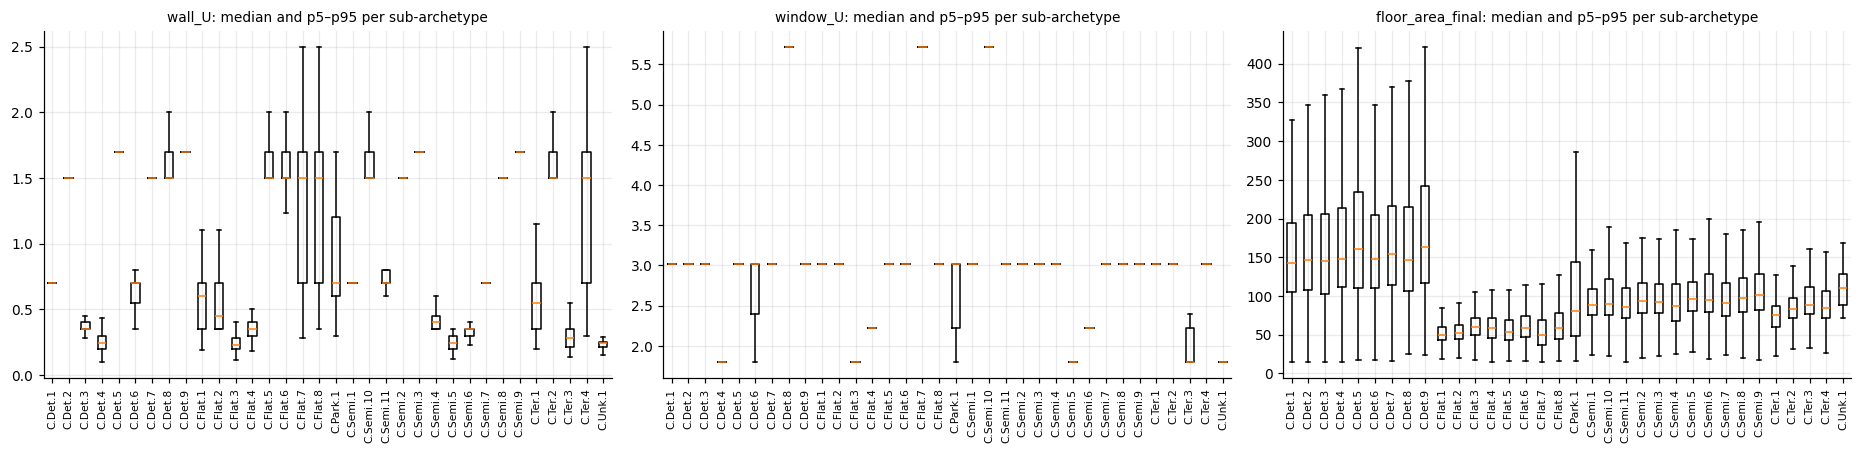

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(max(15, 0.5 * len(cluster_ids)), 4.2))
for ax, col in zip(axes, ["wall_U", "window_U", "floor_area_final"]):
    data = [lab.loc[lab["cluster"] == cid, col].dropna() for cid in cluster_ids]
    ax.boxplot(data, tick_labels=[names[c] for c in cluster_ids], showfliers=False)
    ax.set_title(f"{col}: median and p5–p95 per sub-archetype", fontsize=9); ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout(); fig.savefig(FIG / "02_fabric_ranges.png", bbox_inches="tight"); plt.show()

## 2 · The per-dwelling input table

Each dwelling keeps its own geometry and its own U-values. The calibration (notebook 06) acts through
stock-wide scalers on the envelope, infiltration, gains and setpoints — the bounds are in
`parameters/demand_model/calibration.json`; the archetype fabric ranges exported here document how much of
that range the stock itself spans.

In [5]:
from ukubem import params as PRM
G = PRM.load("demand_model", "geometry_defaults")
fabric_ig = {cid: representatives[int(cid)]["fabric"] for cid in cluster_ids}
inputs = lab[["UPRN", "toid", "LSOA", "ward", "in_study_area", "postcode", "attributes_observed", "lon", "lat",
              "accommodation_type", "built_form", "age_band_resolved", "tenure", "heat_system",
              "wall_construction_resolved", "wall_insulation", "glazing_type", "roof_type",
              "floor_area_final", "storeys_est", "height_eaves_m", "height_ridge_m", "area_m2", "volume_m3", "uprn_count",
              "is_flat_roof", "roof_exposed", "wall_U", "roof_U", "window_U", "window_SHGC", "age_band_ord",
              "cluster", "systems_fam", "archetype"] + [c for c in EXTRA_LABELS if c in lab.columns]].copy()
inputs["construction_sa"] = inputs["cluster"].map(names)
for k in ("wall_U", "roof_U", "window_U"):
    inputs[f"{k}_archetype_guess"] = inputs["cluster"].map(lambda c: fabric_ig[c][k]["initial_guess"])
    inputs[f"{k}_archetype_p5"] = inputs["cluster"].map(lambda c: fabric_ig[c][k]["feasible_range"][0])
    inputs[f"{k}_archetype_p95"] = inputs["cluster"].map(lambda c: fabric_ig[c][k]["feasible_range"][1])
inputs["heating_setpoint_C"] = G["default_setpoint_c"]; inputs["heating_setback_C"] = G["default_setback_c"]
inputs["internal_gains_W_m2"] = G["default_gains_w_m2"]; inputs["window_to_wall_ratio"] = G["window_to_wall_ratio"]
inputs["weather_epw"] = EPW.name
inputs.to_parquet(EXPORT_DIR / "dwelling_inputs.parquet"); inputs.head(1000).to_csv(EXPORT_DIR / "dwelling_inputs_sample.csv")
cal = PRM.load("demand_model", "calibration")
calib_params = {"objective": cal["objective"], "physics_bounds": cal["physics_bounds"], "fixed_post_processing": cal["fixed_post_processing"],
                "aggregation_weights": "calibration_targets_lsoa.csv (sub-archetype counts per LSOA)",
                "archetype_fabric_ranges": {names[cid]: {k: fabric_ig[cid][k] for k in ("wall_U", "roof_U", "window_U")} for cid in cluster_ids}}
json.dump(H.json_safe(calib_params), open(EXPORT_DIR / "calibration_parameters.json", "w"), indent=2)
for src in ("subarchetypes_construction.json", "subarchetypes_systems.json"):
    (EXPORT_DIR / src).write_text((CLUSTERS_DIR / src).read_text())
print(f"dwelling_inputs.parquet: {inputs.shape[0]:,} rows x {inputs.shape[1]} columns")
inputs.iloc[0]

dwelling_inputs.parquet: 57,300 rows x 64 columns


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


## 3 · Calibration interface: LSOA × sub-archetype composition and the DESNZ benchmark

84 LSOAs; DESNZ gas mean present for 84 of them


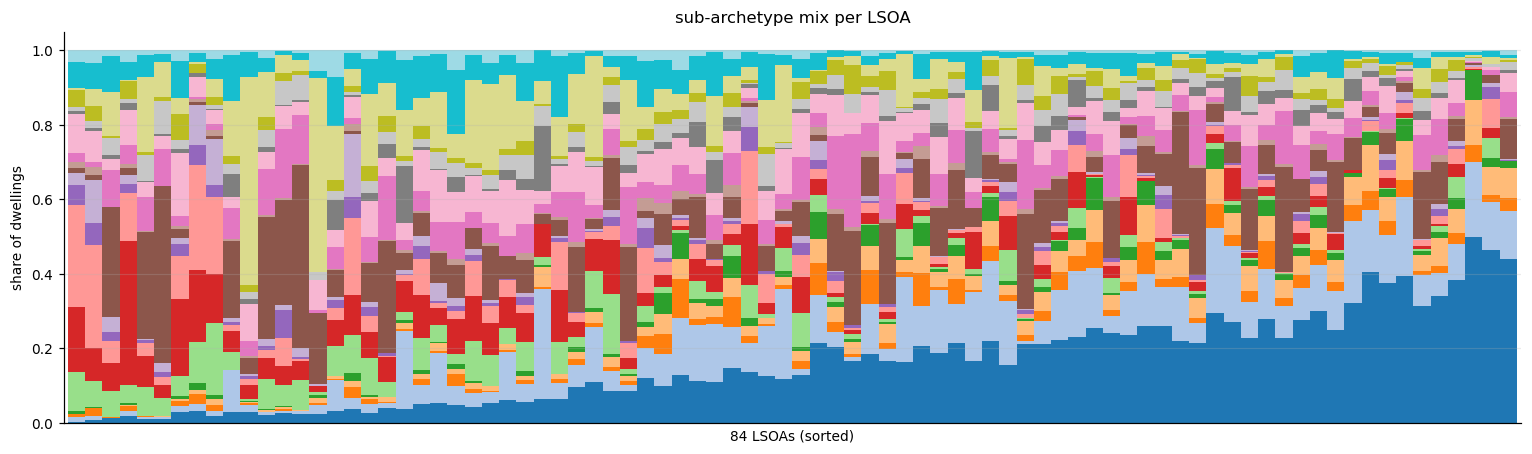

exports in outputs/representatives/:
  calibration_parameters.json                         16 kB
  calibration_targets_lsoa.csv                        16 kB
  cluster_representatives.csv                          6 kB
  cluster_representatives.json                       128 kB
  dwelling_inputs.parquet                           4451 kB
  dwelling_inputs_sample.csv                         598 kB
  subarchetypes_construction.json                     42 kB
  subarchetypes_systems.json                           3 kB


[None, None, None, None, None, None, None, None]

In [6]:
comp = pd.crosstab(lab["LSOA"], lab["cluster"]); comp.columns = [f"cluster_{c}" for c in comp.columns]; comp["dwellings"] = comp.sum(axis=1)
gas_boiler = lab["heat_system"].eq("Gas boiler").groupby(lab["LSOA"]).sum().rename("gas_boiler_dwellings")
targets = comp.join(gas_boiler).join(bench_lsoa.set_index("LSOA")[["gas_meters", "gas_mean_kWh", "gas_median_kWh", "elec_meters", "elec_mean_kWh", "elec_median_kWh"]])
targets.to_csv(EXPORT_DIR / "calibration_targets_lsoa.csv")
print(f"{len(targets)} LSOAs; DESNZ gas mean present for {targets['gas_mean_kWh'].notna().sum()} of them")
share = comp[[c for c in comp.columns if c.startswith("cluster_")]].div(comp["dwellings"], axis=0)
share.columns = [names[int(c.split("_")[1])] for c in share.columns]
fig, ax = plt.subplots(figsize=(14, 4.2))
share.sort_values(share.columns[0]).plot.bar(stacked=True, ax=ax, width=1.0, colormap="tab20", legend=False)
ax.set_xticks([]); ax.set_xlabel(f"{len(share)} LSOAs (sorted)"); ax.set_ylabel("share of dwellings"); ax.set_title("sub-archetype mix per LSOA")
plt.tight_layout(); fig.savefig(FIG / "02_lsoa_archetype_mix.png", bbox_inches="tight"); plt.show()
print(f"exports in outputs/{EXPORT_DIR.name}/:"); [print(f"  {p.name:45s} {p.stat().st_size/1e3:8.0f} kB") for p in sorted(EXPORT_DIR.glob('*'))]

**Next:** `03_engine_setup.ipynb` — the ISO 52016 hourly engine on one dwelling, then on every representative.